<a href="https://colab.research.google.com/github/Jhairzp27/VitalsFlow/blob/main/01_Exploracion_y_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del archivo
df = pd.read_csv('healthcare_dataset.csv')

# Inspección Visual y Estructural

In [12]:
print("----Primeras 5 filas:----\n")
display(df.head())

print("\n----Estructura del dataset (Filas, Columnas):-----\n")
print(df.shape)

print("\n----Tipos de datos y valores no nulos:----\n")
print(df.info())

----Primeras 5 filas:----



,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



----Estructura del dataset (Filas, Columnas):-----

(55500, 15)

----Tipos de datos y valores no nulos:----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  objec

# Identificación de Problemas

In [13]:
print("---Valores nulos por columna:----")
print(df.isnull().sum())

print("\n----Registros duplicados:----\n")
print(df.duplicated().sum())

print("\n----Valores únicos en columnas categóricas (Género, Tipo de Sangre, Condición):----\n")
for col in ['Gender', 'Blood Type', 'Medical Condition']:
    print(f"{col}: {df[col].unique()}")

---Valores nulos por columna:----
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

----Registros duplicados:----

534

----Valores únicos en columnas categóricas (Género, Tipo de Sangre, Condición):----

Gender: ['Male' 'Female']
Blood Type: ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
Medical Condition: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']


### Visualización y caza de nulos ocultos

--- CAZA DE NULOS OCULTOS ---
Búsqueda de textos sospechosos finalizada.

--- ANÁLISIS DE VALORES NUMÉRICOS ---
Edad mínima: 13 | Edad máxima: 89
Facturación mínima: -2008.4921398591305 | Facturación máxima: 52764.276736469175



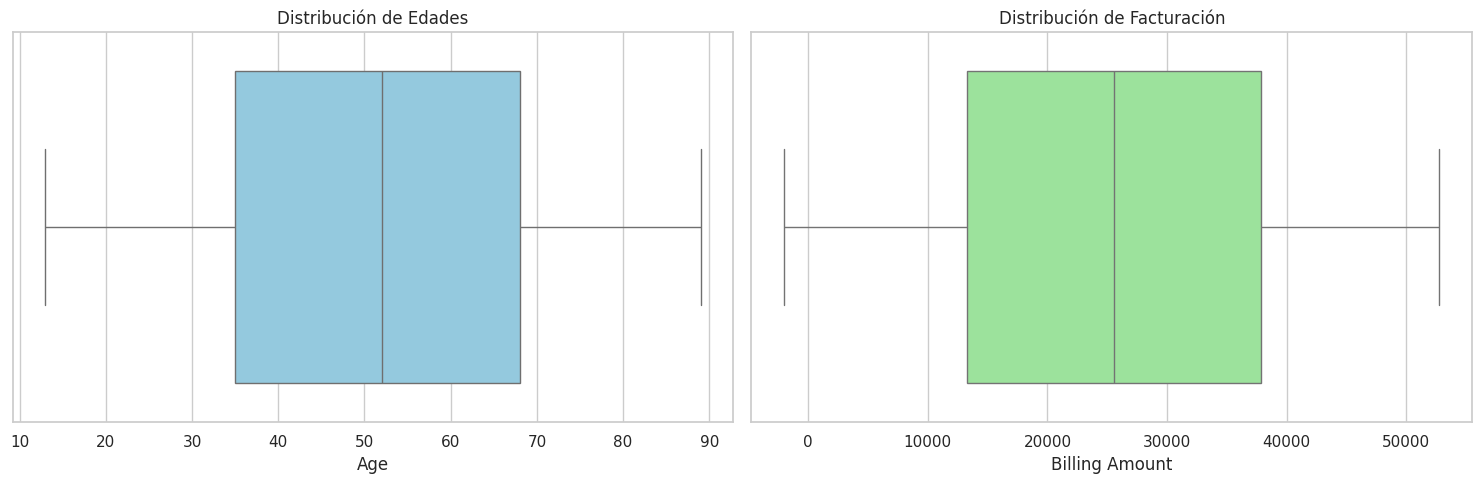

In [14]:
# Configuracion del estilo de los gráficos
sns.set_theme(style="whitegrid")

print("--- CAZA DE NULOS OCULTOS ---")
# Buscamos strings vacíos o palabras comodín en las columnas de texto
for col in df.select_dtypes(include=['object']).columns:
    sospechosos = df[df[col].astype(str).str.strip().isin(['', 'N/A', 'None', 'Unknown', '-', 'null'])]
    if len(sospechosos) > 0:
        print(f"⚠️ ¡Ojo! La columna '{col}' tiene {len(sospechosos)} valores sospechosos ocultos.")
print("Búsqueda de textos sospechosos finalizada.\n")

print("--- ANÁLISIS DE VALORES NUMÉRICOS ---")
print(f"Edad mínima: {df['Age'].min()} | Edad máxima: {df['Age'].max()}")
print(f"Facturación mínima: {df['Billing Amount'].min()} | Facturación máxima: {df['Billing Amount'].max()}\n")

# Gráficos (Boxplots) para ver la distribución de la data numérica
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edades')

sns.boxplot(x=df['Billing Amount'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Facturación')

plt.tight_layout()
plt.show()

Al tener una facturación en negativo, me adentro a revisar a detalle, filtro el DataFrame para ver solo las facturas menores a 0

In [15]:
facturas_negativas = df[df['Billing Amount'] < 0]

print(f"\n---Encontramos {len(facturas_negativas)} registro(s) con facturación negativa.----")
display(facturas_negativas)


---Encontramos 108 registro(s) con facturación negativa.----


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52894,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive
53204,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
53232,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
54136,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal


Después de leer la documentación propuesta en kaggle no encuentro una explicación a montos negativos, por lo que sospecho de un error de computo para intentar generar una distribución normal con una campana de Gauss

### Análisis Univariable de variables categóricas

Para entender la composición de nuestro dataset sintético, dividiremos el análisis visual en dos dimensiones clave: **Demográfica** y **Clínica**.

#### Demográfica

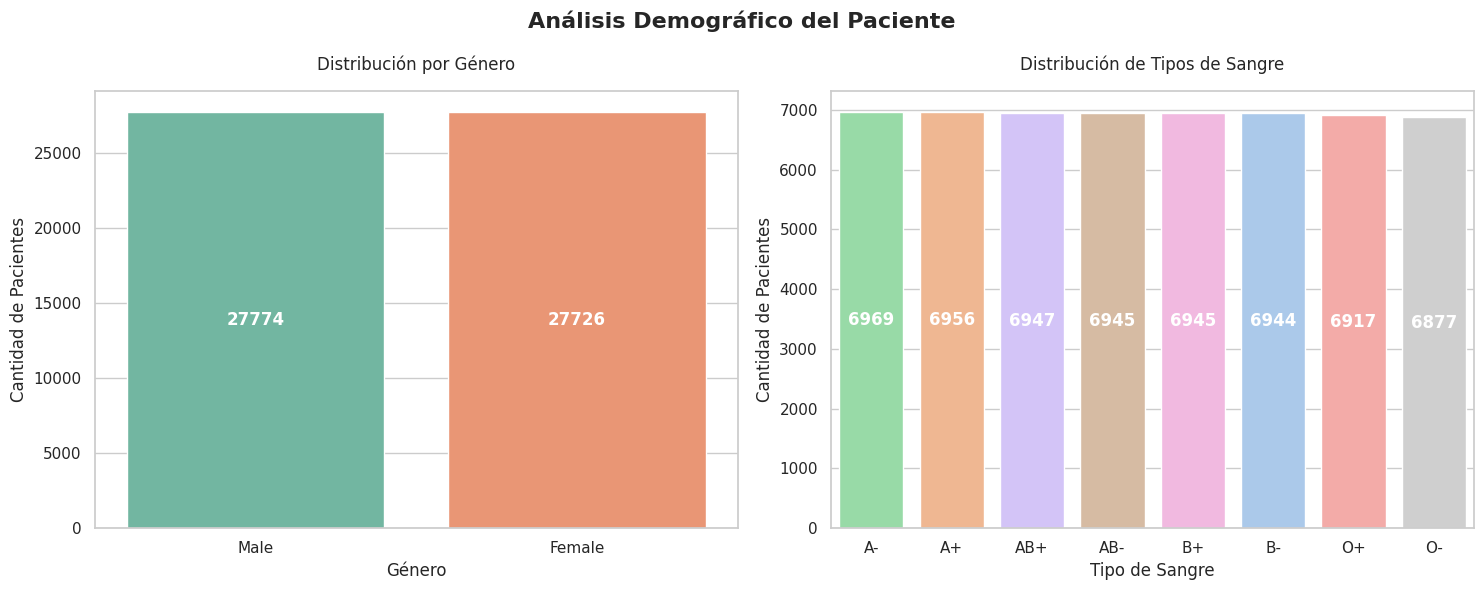

In [9]:
# 1. PERFIL DEMOGRÁFICO (Género y Tipo de Sangre)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Análisis Demográfico del Paciente', fontsize=16, fontweight='bold')

# Gráfico de Género
sns.countplot(data=df, x='Gender', hue='Gender', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Distribución por Género', pad=15)
axes[0].set_ylabel('Cantidad de Pacientes')
axes[0].set_xlabel('Género')
# Agregamos las etiquetas centradas y en blanco para todas las barras
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='center', color='white', weight='bold')

# Gráfico de Tipo de Sangre
sns.countplot(data=df, x='Blood Type', hue='Blood Type', ax=axes[1], palette='pastel',
              order=df['Blood Type'].value_counts().index, legend=False)
axes[1].set_title('Distribución de Tipos de Sangre', pad=15)
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].set_xlabel('Tipo de Sangre')
for container in axes[1].containers:
    axes[1].bar_label(container, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

#### Clínico

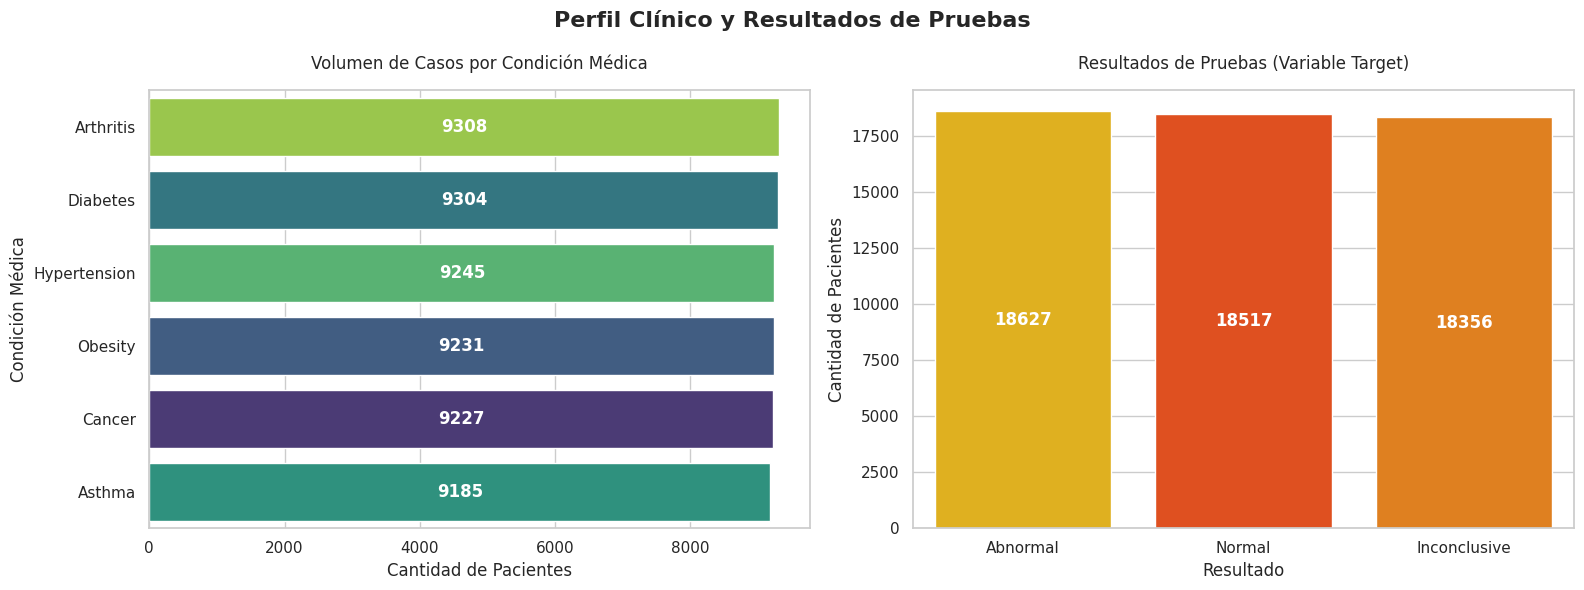

In [10]:
# 2. PERFIL CLÍNICO (Condiciones y Resultados)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perfil Clínico y Resultados de Pruebas', fontsize=16, fontweight='bold')

# Gráfico de Condición Médica (Horizontal)
sns.countplot(data=df, y='Medical Condition', hue='Medical Condition', ax=axes[0], palette='viridis',
              order=df['Medical Condition'].value_counts().index, legend=False)
axes[0].set_title('Volumen de Casos por Condición Médica', pad=15)
axes[0].set_xlabel('Cantidad de Pacientes')
axes[0].set_ylabel('Condición Médica')
for container in axes[0].containers:
    axes[0].bar_label(container, label_type='center', color='white', weight='bold')

# Gráfico de Resultados
sns.countplot(data=df, x='Test Results', hue='Test Results', ax=axes[1], palette='autumn',
              order=df['Test Results'].value_counts().index, legend=False)
axes[1].set_title('Resultados de Pruebas (Variable Target)', pad=15)
axes[1].set_ylabel('Cantidad de Pacientes')
axes[1].set_xlabel('Resultado')
for container in axes[1].containers:
    axes[1].bar_label(container, label_type='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

#### Análisis de variables categóricas

Al observar las etiquetas de datos en ambos perfiles (Demográfico y Clínico), hemos descubierto un patrón inusual para el mundo real: una distribución casi perfectamente uniforme.


 * Perfil Demográfico: La proporción entre hombres (27,774) y mujeres (27,726) es exacta al ~50%. Más revelador aún, los 8 tipos de sangre tienen volúmenes casi idénticos (entre 6,877 y 6,969 pacientes). En la realidad demográfica, los tipos O+ y A+ son mayoritarios, mientras que el AB- es extremadamente raro.

* Perfil Clínico: Las 6 condiciones médicas (Artritis, Diabetes, etc.) se agrupan en un rango muy estrecho de apróximadamente 9,200 pacientes cada una. Lo mismo ocurre con los resultados de las pruebas, divididos casi en tercios perfectos (~18,500 por categoría).

Esta simetría matemática confirma visualmente la documentación original del proyecto: el dataset fue generado mediante algoritmos (librería `Faker`). Conocer esto es fundamental, ya que nos da la seguridad operativa de aplicar reglas de limpieza estrictas (como convertir la facturación negativa a valor absoluto) sabiendo que son artefactos del algoritmo de generación y no fraudes financieros o excepciones contables reales del hospital.

# Diagnóstico Final: Fase de Exploración (EDA)

Tras realizar la inspección técnica y visual del dataset, se han identificado los siguientes hallazgos críticos que dictarán la estrategia de la Fase de Limpieza:

1. **Integridad Estructural y Valores Nulos:**
   * A nivel de sistema, la función `isnull()` reporta 0 nulos.

2. **Detección de Duplicados:**
   * Se encontraron **534 registros exactamente duplicados** que inflarían artificialmente cualquier métrica de volumen.
   * *Hallazgo crítico:* Se detectaron "duplicados parciales" o errores de tipeo (ej. pacientes con el mismo nombre exacto, fecha de ingreso, hospital y facturación exacta con múltiples decimales, pero con una variación menor en la edad). Esto requerirá una estrategia de deduplicación basada en un subconjunto de columnas clave (identidad y evento), no solo en la fila completa.

3. **Anomalías Financieras y Numéricas:**
   * La variable `Billing Amount` presenta 108 registros con **valores negativos** y una cantidad excesiva de decimales flotantes. Tras cruzar estas anomalías con el resto del historial clínico del paciente (el cual es normal), se concluye que es un error de signo propio de la generación de datos.

4. **Naturaleza del Dataset:**
   * El análisis univariable demostró una distribución matemática casi perfectamente uniforme (~50% en género, proporciones idénticas en tipos de sangre y condiciones médicas).
   * *Conclusión:* Esto valida la documentación original del dataset, confirmando que la data es **sintética** (generada vía `Faker`). Esta certeza nos da la justificación de negocio para aplicar transformaciones absolutas (como aplicar valor absoluto a la facturación) sabiendo que son artefactos del algoritmo generador y no fraudes contables reales.

**Siguiente Paso:** Proceder a la Fase 2 (Limpieza y Transformación) para estandarizar textos, castear las fechas a formato `datetime`, manejar los valores financieros atípicos y aplicar las reglas de deduplicación.